# Checking out the (possibly) most promising dataset

... though that _possibly_ is yet to be confirmed:
- there are no road annotations
- would need to crop large tiles and curate appropriately
- and found some irregularities in the data..?

Still, it has uniform ground resolution, a lot of images, and bounding boxes which make sampling (and transforms) relatively easy.


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('..')

import src.plotting as splot
import src.data_utils as sduti

## Set up namespace, e.g. point to data

In [3]:
def filter_di( dict_, func_):
    return {k:v for k,v in dict_.items() if func_((k,v))}

def filter_li( list_, func_):
    return [l for l in list_ if func_(l)]

def center_on_bbox( bbox, res, xmax, ymax):
    x1, y1, x2, y2 = bbox
    x, y = x1 + int( (x2 - x1)/2), y1 + int( (y2 - y1)/2)    
    x1_, x2_ = x - int( res/2), int(x + res/2)    
    y1_, y2_ = y - int( res/2), int(y + res/2)    
    try:
        assert x1_ >= 0 and x2_ <= xmax and y1_ >=0 and y2_ <= ymax
        return (x1_, y1_, x2_, y2_),(x1 - x1_, y1 - y1_, x2 - x1_, y2 - y1_)
    except AssertionError:
        return None, None

def crop_to_bbox( image_array, bbox):
    x1, y1, x2, y2 = bbox
    return image_array[:,x1:x2,:][y1:y2,:,:]

In [4]:
data_path = '../../xView-train_images/'
label_file = '../../xView_train.geojson'

In [6]:
labelnames_di = {
    11:'Fixed-wing Aircraft', 12:'Small Aircraft', 13:'Passenger/Cargo Plane', 15:'Helicopter',
    17:'Passenger Vehicle', 18:'Small Car', 19:'Bus', 20:'Pickup Truck', 21:'Utility Truck',
    23:'Truck', 24:'Cargo Truck', 25:'Truck Tractor w/ Box Trailer', 26:'Truck Tractor',27:'Trailer',
    28:'Truck Tractor w/ Flatbed Trailer', 29:'Truck Tractor w/ Liquid Tank', 32:'Crane Truck',
    33:'Railway Vehicle', 34:'Passenger Car', 35:'Cargo/Container Car', 36:'Flat Car', 37:'Tank car',
    38:'Locomotive', 40:'Maritime Vessel', 41:'Motorboat', 42:'Sailboat', 44:'Tugboat', 45:'Barge',
    47:'Fishing Vessel', 49:'Ferry', 50:'Yacht', 51:'Container Ship', 52:'Oil Tanker',
    53:'Engineering Vehicle', 54:'Tower crane', 55:'Container Crane', 56:'Reach Stacker',
    57:'Straddle Carrier', 59:'Mobile Crane', 60:'Dump Truck', 61:'Haul Truck', 62:'Scraper/Tractor',
    63:'Front loader/Bulldozer', 64:'Excavator', 65:'Cement Mixer', 66:'Ground Grader', 71:'Hut/Tent',
    72:'Shed', 73:'Building', 74:'Aircraft Hangar', 76:'Damaged Building', 77:'Facility', 79:'Construction Site',
    83:'Vehicle Lot', 84:'Helipad', 86:'Storage Tank', 89:'Shipping container lot', 91:'Shipping Container',
    93:'Pylon', 94:'Tower'}
labelnames_di_ = {v:k for k,v in labelnames_di.items()}

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [8]:
label_di = sduti.from_json( label_file)
for k,v in label_di.items():
    print(k,type(v))

crs <class 'dict'>
type <class 'str'>
features <class 'list'>
name <class 'str'>


In [9]:
label_di['crs'], label_di['type'], label_di['name'], len(label_di['features'])

({'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}, 'type': 'name'},
 'FeatureCollection',
 'U-LIMDIS_xView_Final',
 601937)

In [10]:
label_li = label_di['features']
label_li[0]

{'type': 'Feature',
 'properties': {'bounds_imcoords': '2712,1145,2746,1177',
  'edited_by': 'wwoscarbecerril',
  'cat_id': '1040010028371A00',
  'type_id': 73,
  'ingest_time': '2017/07/24 12:49:09.118+00',
  'index_right': 2356,
  'image_id': '2355.tif',
  'point_geom': '0101000020E6100000616E4E6406A256C03BE6ADA0D6212D40',
  'feature_id': 374410,
  'grid_file': 'Grid2.shp'},
 'geometry': {'type': 'Polygon',
  'coordinates': [[[-90.53169885094464, 14.56603647302396],
    [-90.53169885094464, 14.56614473506768],
    [-90.53158140073565, 14.56614473506768],
    [-90.53158140073565, 14.56603647302396],
    [-90.53169885094464, 14.56603647302396]]]}}

In [11]:
labelnames_di.keys()

dict_keys([11, 12, 13, 15, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 44, 45, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 64, 65, 66, 71, 72, 73, 74, 76, 77, 79, 83, 84, 86, 89, 91, 93, 94])

In [12]:
candidates = ['Passenger Vehicle','Small Car','Bus','Pickup Truck','Utility Truck','Truck','Cargo Truck']

In [13]:
im_name = '2355.tif'

In [14]:
subset = filter_li( label_li, lambda x: x['properties']['image_id']== im_name)

In [15]:
subset_b = filter_li( subset, lambda x: labelnames_di[ x['properties']['type_id']] in ('Building'))
len(subset_b)

1946

In [16]:
subset_c = filter_li( subset, lambda x: labelnames_di[ x['properties']['type_id']] in candidates)
len(subset_c)

362

In [17]:
image_ = sduti.to_numpy( sduti.load_image( f'{data_path}{im_name}'))
xmax, ymax, _ = image_.shape
image_.shape

(2667, 2739, 3)

In [18]:
get_bbox = lambda x: [int(y) for y in x['properties']['bounds_imcoords'].split(',')]
get_bbox( subset[0])

[2712, 1145, 2746, 1177]

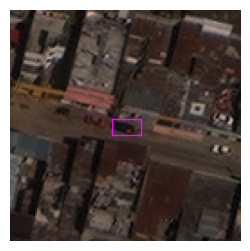

In [20]:
bbox = get_bbox( subset_c[308])
image_bbox, bbox_inner = center_on_bbox( bbox, 128, xmax, ymax)
if image_bbox is not None:
    ax = splot.plot_single( crop_to_bbox( image_, image_bbox), figsize= (3,3))
    splot.plot_bbox( *bbox_inner, ax= ax)

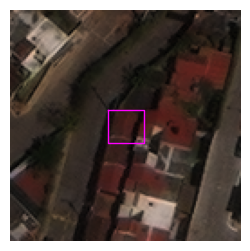

In [21]:
bbox = get_bbox( subset_b[303])
image_bbox, bbox_inner = center_on_bbox( bbox, 128, xmax, ymax)
if image_bbox is not None:
    ax = splot.plot_single( crop_to_bbox( image_, image_bbox), figsize= (3,3))
    splot.plot_bbox( *bbox_inner, ax= ax)